# Simulación numérica de sistemas dinámicos aplicada a ciberseguridad
Stefano Francolino · Cálculo Aplicado · Universidad Católica del Uruguay

Ejecutar todas las celdas en orden. Los modelos son hipotéticos y el tiempo se expresa en unidades genéricas.

## Métodos y contrato
Euler usa la pendiente inicial; Heun predice el estado final y promedia dos pendientes. Ambos devuelven tiempos, aproximaciones y pasos, incluyen el punto inicial y ajustan el último paso. No se ocultan estados negativos.

In [1]:
from pathlib import Path
import sys
raiz = Path.cwd()
if not (raiz / 'src').exists():
    raiz = raiz.parent
assert (raiz / 'src').exists(), 'Abrir desde la raíz del proyecto o notebooks/'
sys.path.insert(0, str(raiz))
from src.metodos import euler, euler_mejorado
from src.experimentos import ejecutar
from IPython.display import display, Image
import numpy as np
import pandas as pd
datos = ejecutar(raiz)
def figura(nombre):
    display(Image(filename=str(raiz / 'resultados/figuras' / (nombre+'.png'))))

In [2]:
t, x, pasos = euler_mejorado(lambda t,x: t, 0, 0, 1, .3)
display(pd.DataFrame({'t':t, 'Heun':x, 'referencia t²/2':t*t/2}))
assert pasos == 4 and len(t) == pasos+1 and t[-1] == 1
np.testing.assert_allclose(x, t*t/2, atol=1e-14)

,t,Heun,referencia t²/2
0,0.0,0.000,0.000
1,0.3,0.045,0.045
2,0.6,0.180,0.180
3,0.9,0.405,0.405
4,1.0,0.500,0.500


## 1. Crecimiento lineal
$x\prime=1$, $x(0)=0$, referencia $x=t$, intervalo [0,10]. Al ser constante la pendiente, Euler coincide en los nodos dentro del redondeo. Reducir el paso no garantiza mejorar este caso.

,metodo,h,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones
0,Euler,1.0,10,11,10.0,0.0,0.0,10
1,Euler,0.5,20,21,10.0,0.0,0.0,20
2,Euler,0.1,100,101,10.0,0.0,0.0,100


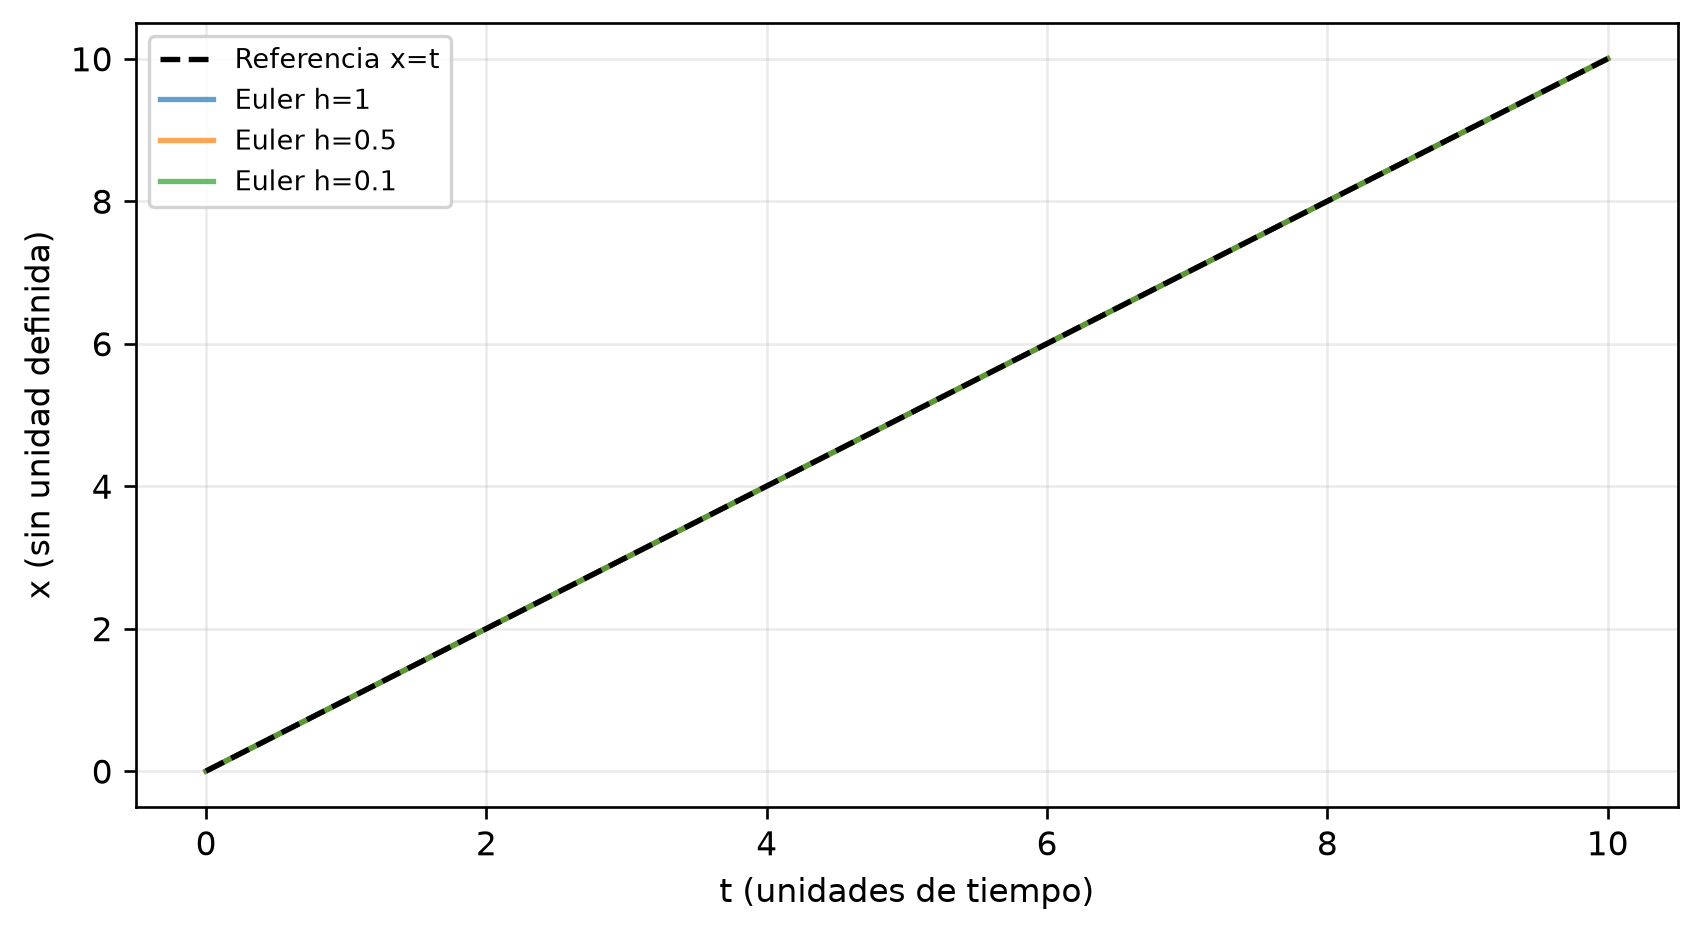

In [3]:
display(datos['lineal'])
figura('lineal')

## 2. Decrecimiento y error
$x\prime=-x$, $x(0)=1$. $E_n=|x_n-e^{-t_n}|$. El error final usa el último nodo, mientras el máximo recorre todos. Con h=1 Euler toma cero desde el primer paso. Se comparan cinco pasos para el error.

,metodo,h,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones
0,Euler,1.00,10,11,0.000000e+00,0.000045,0.367879,10
1,Euler,0.50,20,21,9.536743e-07,0.000044,0.117879,20
2,Euler,0.10,100,101,2.656140e-05,0.000019,0.019201,100
3,Euler,0.05,200,201,3.505267e-05,0.000010,0.009394,200
4,Euler,0.01,1000,1001,4.317125e-05,0.000002,0.001847,1000


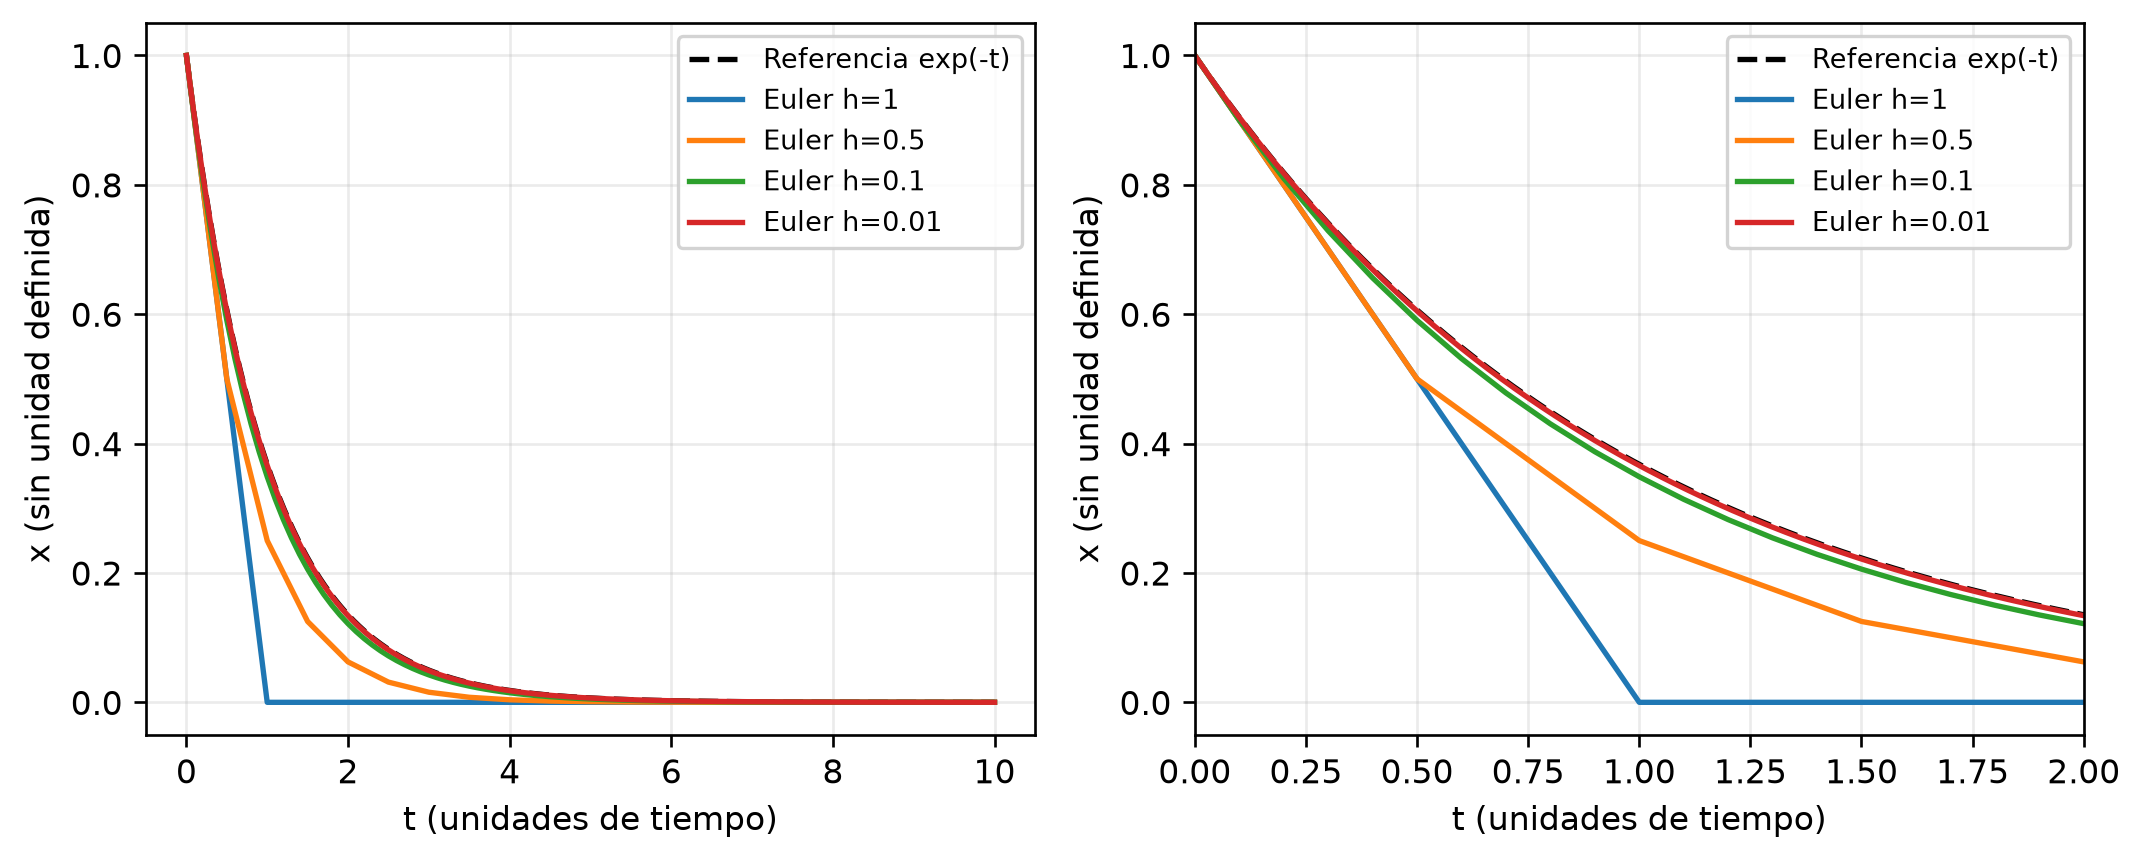

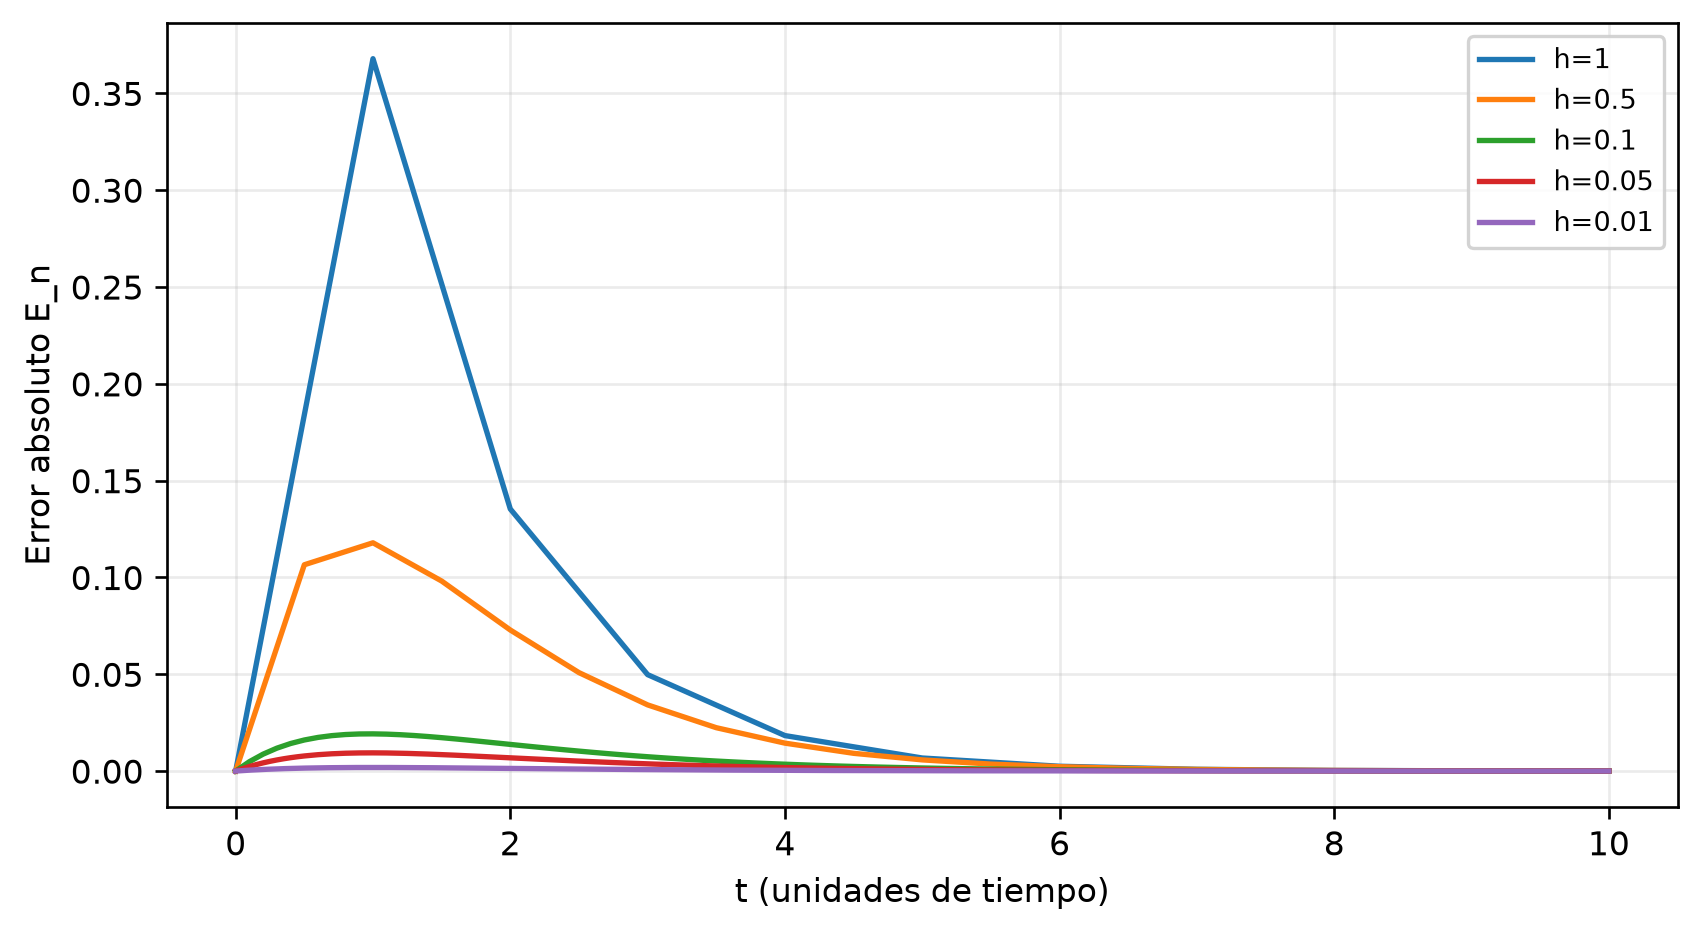

In [4]:
display(datos['error'])
figura('exponencial')
figura('errores')

## 3. Euler frente a Heun
Heun requiere dos evaluaciones por paso. Comparar ambas métricas: con h=1 Euler tiene menor error final, pero Heun menor máximo. La referencia final es muy pequeña, por eso el cero artificial puede quedar más cerca en ese punto.

In [5]:
display(datos['comparacion'])
display(datos['convergencia'])
c = datos['comparacion'].query('h == 1').set_index('metodo')
assert c.loc['Euler','error_final'] < c.loc['Heun','error_final']
assert c.loc['Euler','error_maximo'] > c.loc['Heun','error_maximo']

,metodo,h,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones
0,Euler,1.0,10,11,0.000000e+00,4.539993e-05,0.367879,10
1,Euler,0.5,20,21,9.536743e-07,4.444626e-05,0.117879,20
2,Euler,0.1,100,101,2.656140e-05,1.883853e-05,0.019201,100
3,Heun,1.0,10,11,9.765625e-04,9.311626e-04,0.132121,20
4,Heun,0.5,20,21,8.271806e-05,3.731813e-05,0.022746,40
5,Heun,0.1,100,101,4.622298e-05,8.230481e-07,0.000662,200


,metodo,h,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones,orden_observado
0,Euler,0.2000,50,51,0.000014,3.112745e-05,0.040199,50,NaN
1,Euler,0.1000,100,101,0.000027,1.883853e-05,0.019201,100,1.065994
2,Euler,0.0500,200,201,0.000035,1.034726e-05,0.009394,200,1.031444
3,Euler,0.0250,400,401,0.000040,5.419609e-06,0.004647,400,1.015366
4,Euler,0.0125,800,801,0.000043,2.773060e-06,0.002311,800,1.007597
5,Heun,0.2000,50,51,0.000049,3.656125e-06,0.002860,100,NaN
6,Heun,0.1000,100,101,0.000046,8.230481e-07,0.000662,200,2.112310
7,Heun,0.0500,200,201,0.000046,1.968273e-07,0.000159,400,2.055173
8,Heun,0.0250,400,401,0.000045,4.821276e-08,0.000039,800,2.027323
9,Heun,0.0125,800,801,0.000045,1.193586e-08,0.000010,1600,2.013594


## 4. Remediación de equipos vulnerables
$V\prime=-kV$, $V_0=1000$, A: k=.1, B: .3, C: .7. k es rapidez fraccional, en tiempo inverso. Los decimales son cantidades agregadas, no fracciones de un equipo individual.

,organizacion,k,h,t,aproximacion,referencia,error_absoluto
0,A,0.1,1.0,5,590.490000,606.530660,16.040660
1,A,0.1,1.0,10,348.678440,367.879441,19.201001
2,A,0.1,1.0,15,205.891132,223.130160,17.239028
3,A,0.1,0.5,5,598.736939,606.530660,7.793720
4,A,0.1,0.5,10,358.485922,367.879441,9.393519
5,A,0.1,0.5,15,214.638764,223.130160,8.491396
6,A,0.1,0.1,5,605.006067,606.530660,1.524593
7,A,0.1,0.1,10,366.032341,367.879441,1.847100
8,A,0.1,0.1,15,221.451787,223.130160,1.678373
9,B,0.3,1.0,5,168.070000,223.130160,55.060160


,metodo,h,organizacion,k,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones
0,Euler,1.0,A,0.1,20,21,1.215767e+02,13.758629,19.201001,20
1,Euler,0.5,A,0.1,40,41,1.285122e+02,6.823127,9.393519,40
2,Euler,0.1,A,0.1,200,201,1.339797e+02,1.355608,1.847100,200
3,Euler,1.0,B,0.3,20,21,7.979227e-01,1.680830,63.569660,20
4,Euler,0.5,B,0.3,40,41,1.502301e+00,0.976451,29.420144,40
5,Euler,0.1,B,0.3,200,201,2.261241e+00,0.217511,5.588367,200
6,Euler,1.0,C,0.7,20,21,3.486784e-08,0.000831,196.585304,20
7,Euler,0.5,C,0.7,40,41,3.284992e-05,0.000799,75.312749,40
8,Euler,0.1,C,0.7,200,201,4.972671e-04,0.000334,13.267161,200


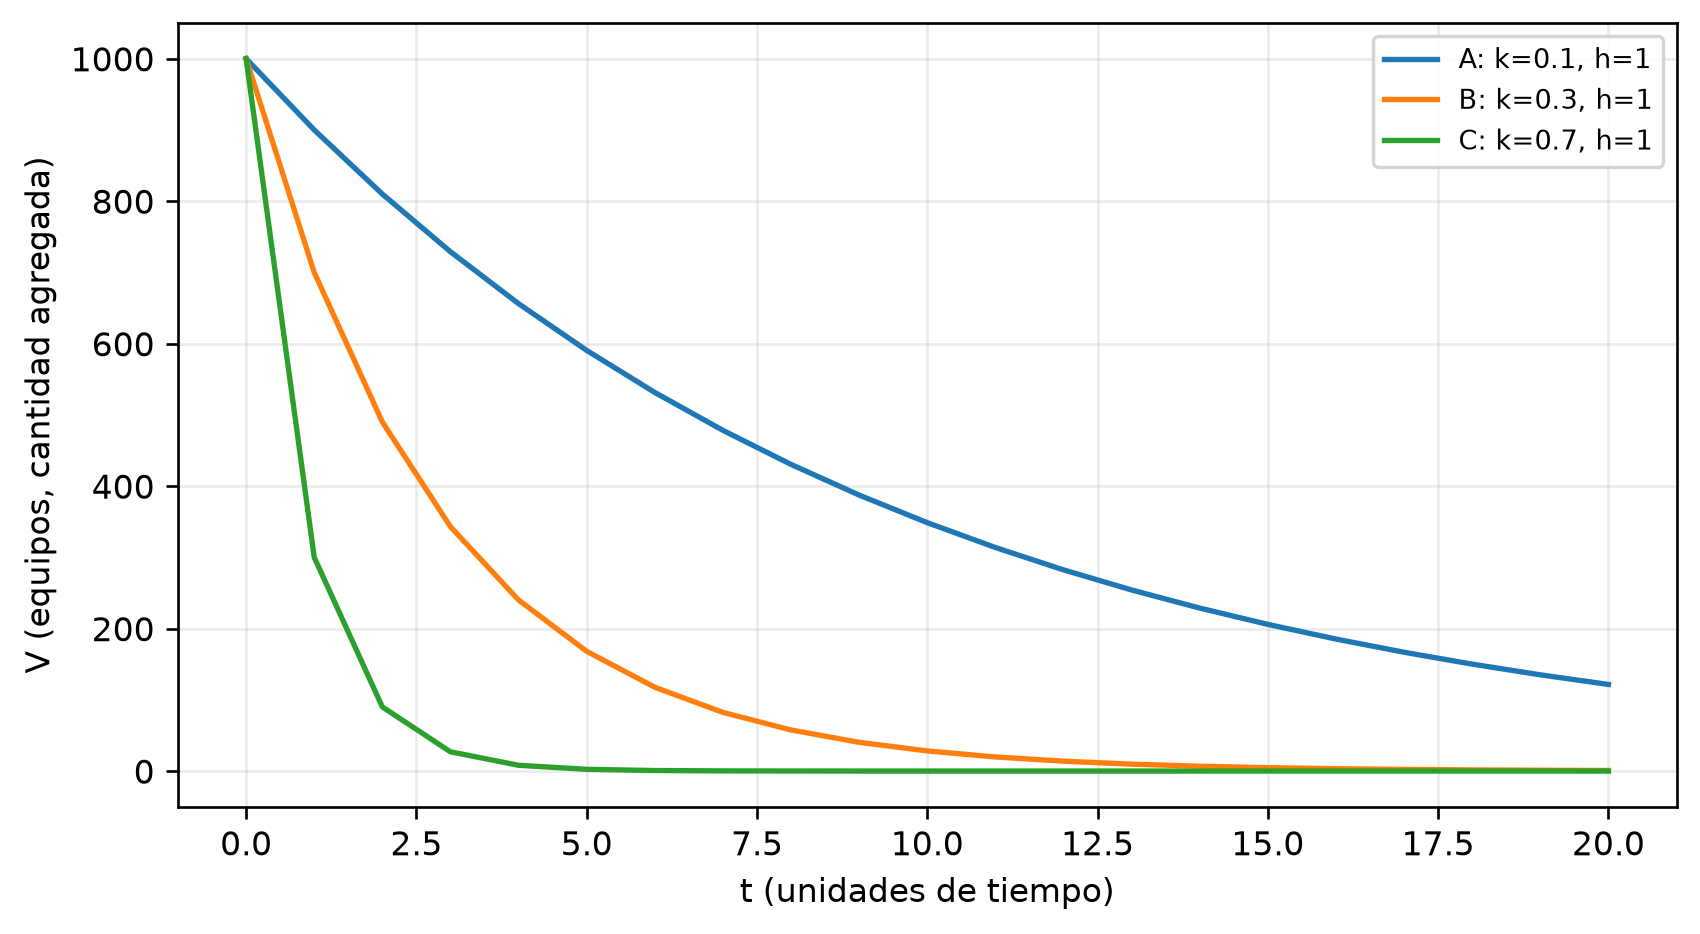

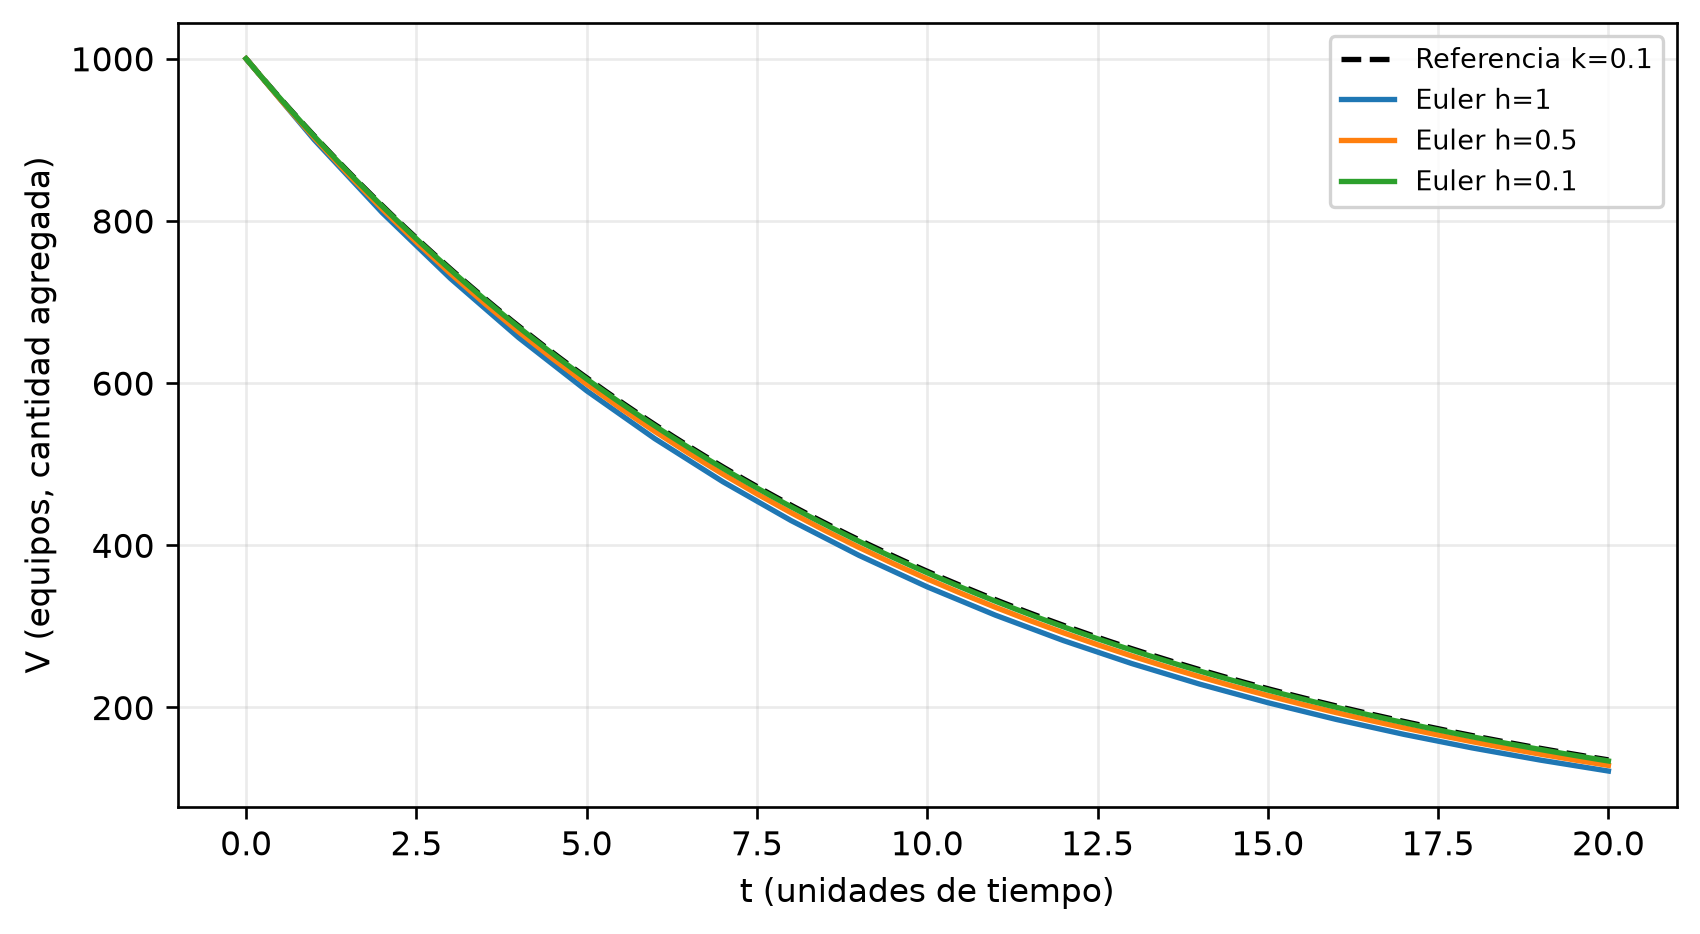

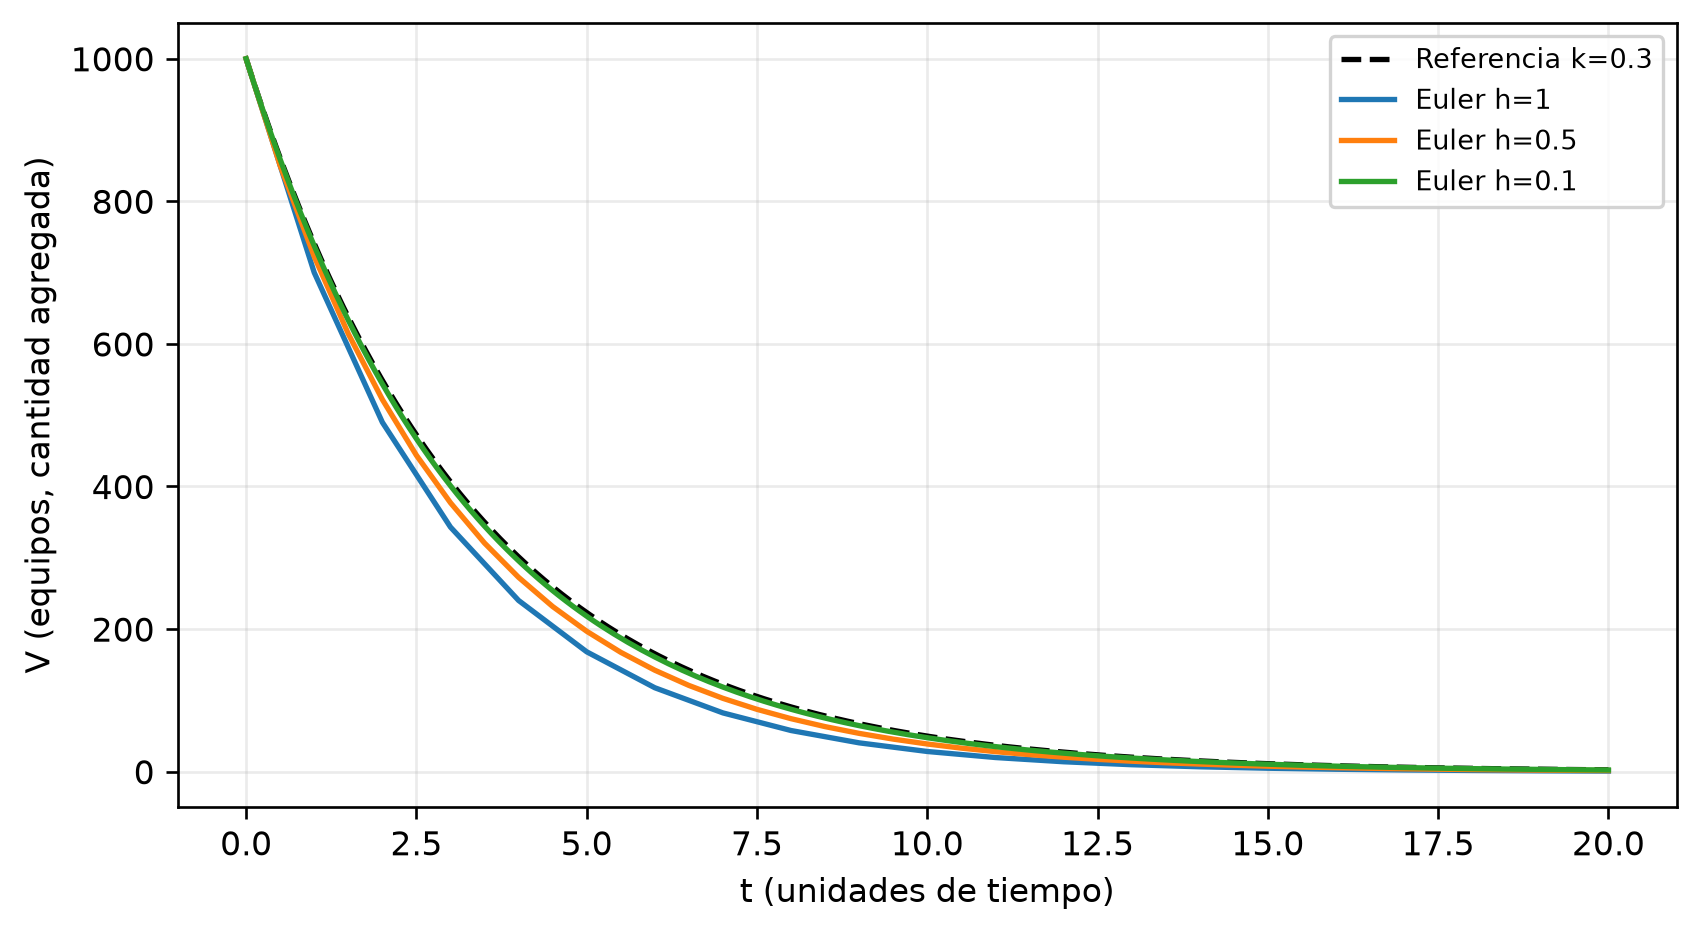

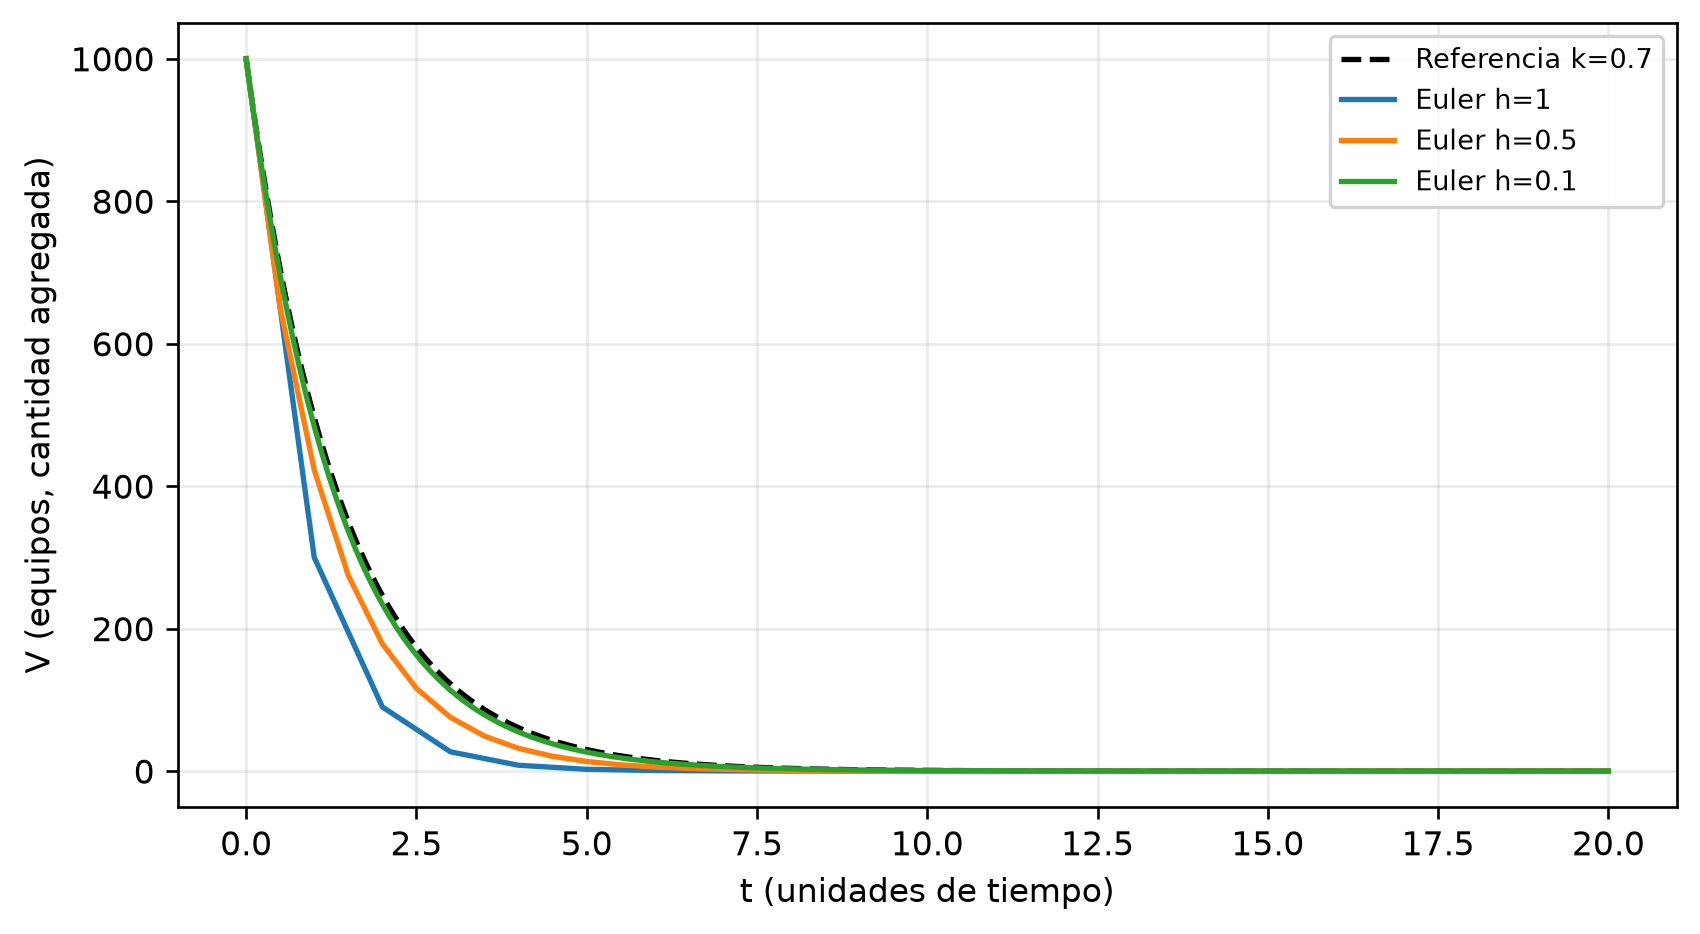

In [6]:
display(datos['vulnerabilidades'])
display(datos['vulnerabilidades_resumen'])
assert len(datos['vulnerabilidades']) == 27
figura('organizaciones')
for org in 'ABC':
    figura('organizacion_'+org)

## 5. Ecuación en diferencias
$V_n=V_0(1-hk)^n$. Para 0<hk<1 hay descenso positivo; hk=1 anula el estado. Para 1<hk<2 alterna signo y converge en magnitud: estabilidad sin validez física. hk=2 alterna sin límite; hk>2 crece en magnitud.

,regimen,signo_monotonia,magnitud,limite,estabilidad_sentido
0,0<hk<1,Positivo; decrece,Disminuye,0,Asintótica; sí
1,hk=1,Cero desde n=1,Se anula,0,Asintótica; extinción artificial
2,1<hk<2,Alternante,Disminuye,0,Asintótica; no
3,hk=2,Alternante,Constante,No existe,Frontera; no
4,hk>2,Alternante,Crece sin cota,No existe,Inestable; no


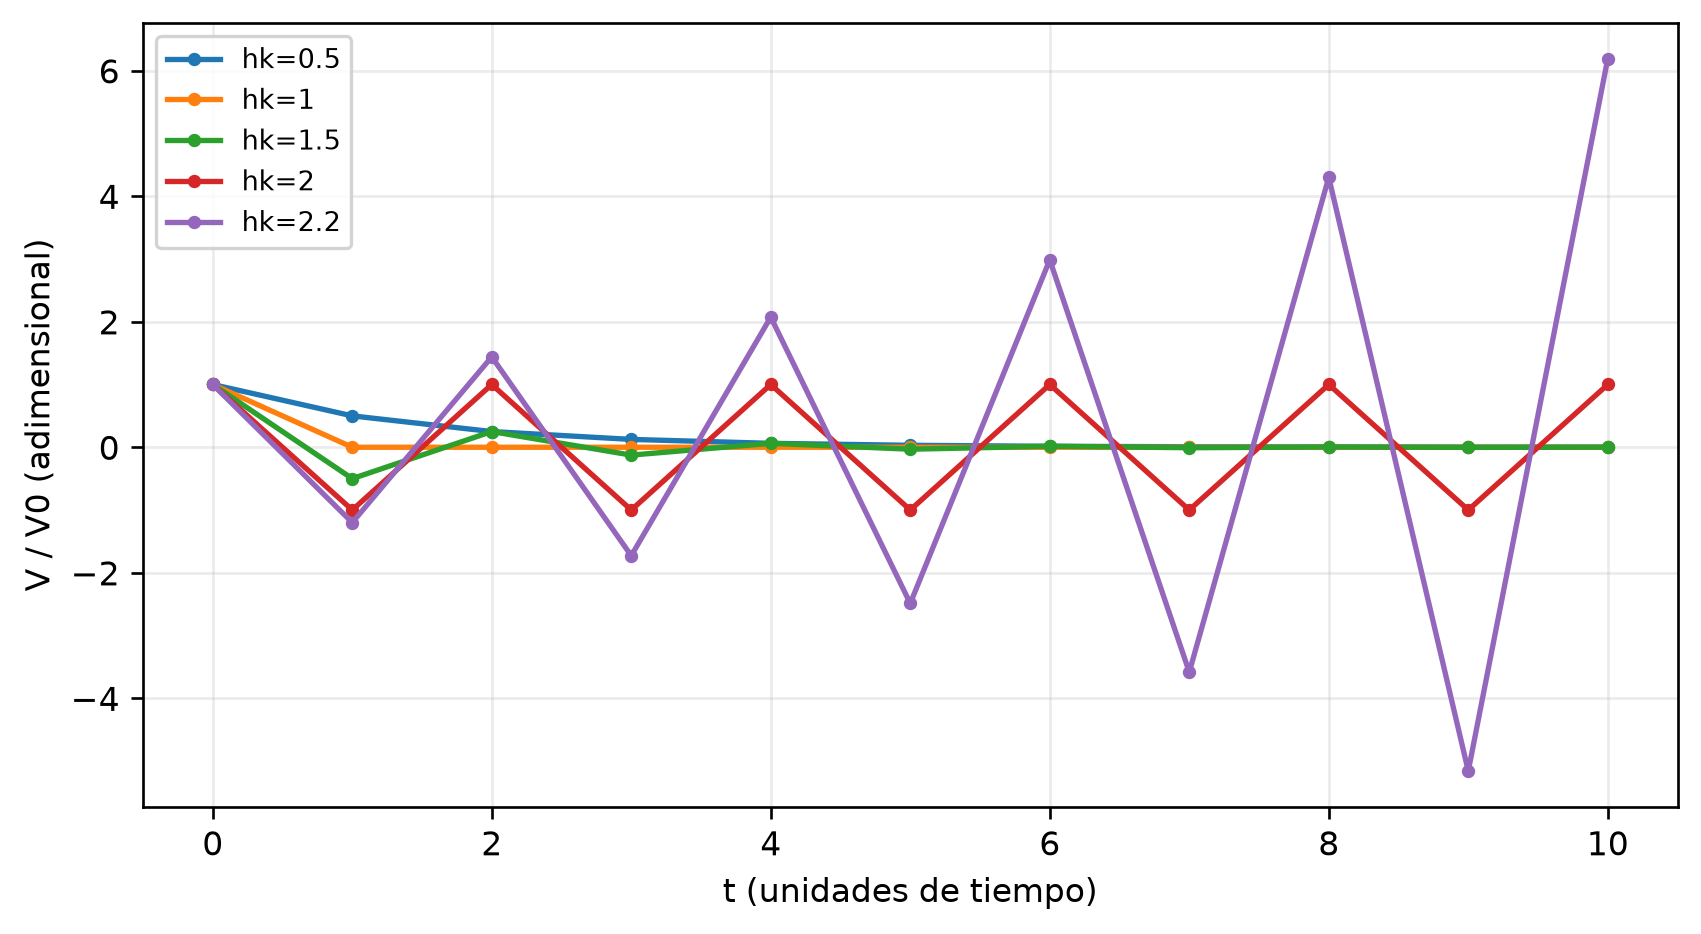

Valores negativos conservados: [ 1.      -0.5      0.25    -0.125    0.0625  -0.03125]


In [7]:
display(pd.read_csv(raiz/'resultados/tablas/clasificacion.csv'))
figura('regimenes')
t,x,n = euler(lambda t,x:-1.5*x,1,0,5,1)
np.testing.assert_allclose(x,(-.5)**np.arange(n+1))
print('Valores negativos conservados:', x)

## 6. Aparición
$V\prime=\lambda-.3V$, V0=1000, h=.1, [0,20]. El equilibrio $V^*=\lambda/.3$ resulta del balance. Todas las condiciones iniciales están por encima del equilibrio, por lo que disminuyen hacia él. Aproximarse no equivale a alcanzarlo.

,metodo,h,lambda_tasa,k,pasos,puntos,valor_final,error_final,error_maximo,evaluaciones,valor_inicial,equilibrio,distancia_equilibrio
0,Euler,0.1,0,0.3,200,201,2.261241,0.217511,5.588367,200,1000,0.000000,2.261241
1,Euler,0.1,50,0.3,200,201,168.551034,0.181259,4.656972,200,1000,166.666667,1.884368
2,Euler,0.1,100,0.3,200,201,334.840827,0.145007,3.725578,200,1000,333.333333,1.507494
3,Euler,0.1,200,0.3,200,201,667.420414,0.072504,1.862789,200,1000,666.666667,0.753747


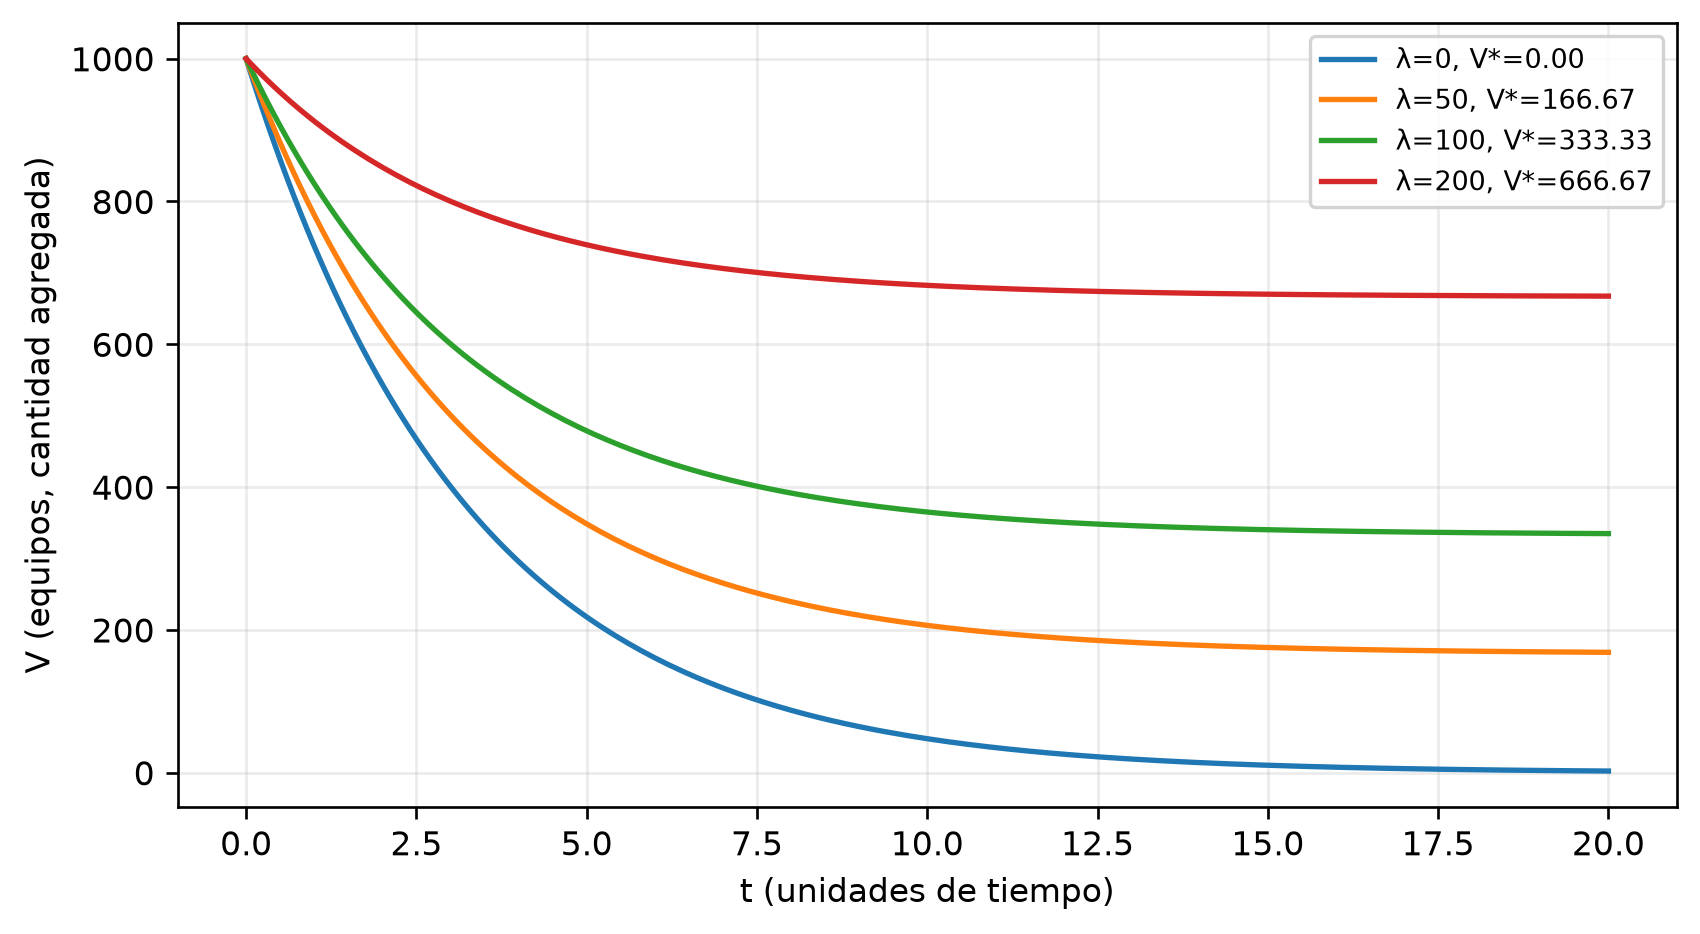

In [8]:
display(datos['extendido'])
figura('extendido')
for lam in [0,50,100,200]:
    eq = lam/.3
    t,x,n = euler(lambda t,x:lam-.3*x,1000,0,20,.1)
    np.testing.assert_allclose(x, eq+(1000-eq)*.97**np.arange(n+1), atol=2e-11)

## Interpretación informática y alcance
CVE identifica una vulnerabilidad; CVSS evalúa severidad; ATT&CK organiza comportamientos adversarios. T1190 se vincula con debilidades de aplicaciones expuestas. La remediación puede acortar exposición, pero el modelo no calcula incidentes ni probabilidades de ataque. Las fuentes y discusión completas están en informe/informe.tex y referencias.bib. Las tasas constantes, homogeneidad y falta de población total limitan la aplicación a organizaciones reales.

## Verificación final
Las pruebas utilizan fórmulas independientes, dependencia explícita de t, ajuste final y entradas inválidas.

In [9]:
import unittest
suite = unittest.defaultTestLoader.discover(str(raiz/'tests'))
resultado = unittest.TextTestRunner(verbosity=2).run(suite)
assert resultado.wasSuccessful()
print('Completado: experimentos, tablas, figuras y pruebas.')

test_combinaciones (test_experimentos.Cobertura.test_combinaciones) ... 

ok


test_convergencia_y_costo (test_experimentos.Cobertura.test_convergencia_y_costo) ... 

ok


test_h_uno_metricas (test_experimentos.Cobertura.test_h_uno_metricas) ... 

...

ok


test_vulnerabilidades (test_metodos.Propiedades.test_vulnerabilidades) ... 

ok


----------------------------------------------------------------------
Ran 15 tests in 0.261s

OK


Completado: experimentos, tablas, figuras y pruebas.
